# Bike Availability Modeling



# Part 1 Feature pairs check


Shape after filter: (298946, 25)
Top 20 by |correlation|:
bikes_1d_mean           0.720048
bikes_same_slot_mean    0.596810
capacity                0.205051
lon                     0.124585
humidity                0.011577
day                     0.003829
weekend                 0.003756
temp                    0.002011
minute                 -0.000847
weekday                -0.000935
number                 -0.001356
pressure               -0.002130
hour                   -0.004754
lat                    -0.137569
num_docks_available    -0.717459
stno                         NaN
year                         NaN
month                        NaN
Name: num_bikes_available, dtype: float64


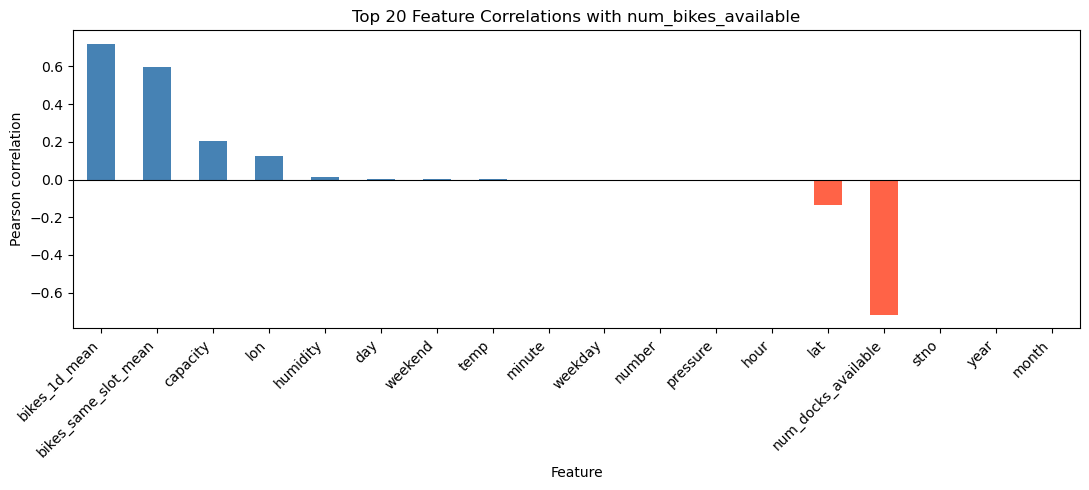

In [2]:
# Part 1: Feature Pair Check（简化版）
import pandas as pd
import matplotlib.pyplot as plt

INTERVALS_PER_DAY = 144  # 10 分钟粒度：1 天 144 条

df_raw = pd.read_csv('final_merged_data.csv.gz', compression='gzip')
if 'number' not in df_raw.columns and 'station_id' in df_raw.columns:
    df_raw = df_raw.rename(columns={'station_id': 'number'})

# 天气/时间特征
df_raw['temp'] = (pd.to_numeric(df_raw['max_air_temperature_celsius']) + pd.to_numeric(df_raw['min_air_temperature_celsius'])) / 2
df_raw['pressure'] = (pd.to_numeric(df_raw['max_barometric_pressure_hpa']) + pd.to_numeric(df_raw['min_barometric_pressure_hpa'])) / 2
hum_avg = (pd.to_numeric(df_raw['max_relative_humidity_percent']) + pd.to_numeric(df_raw['min_relative_humidity_percent'])) / 2
df_raw['humidity'] = (hum_avg > 90).astype(int)
df_raw['weekday'] = pd.to_numeric(df_raw['day']) % 7
df_raw['weekend'] = df_raw['weekday'].isin([5, 6]).astype(int)

# lag 特征（防泄漏）
df_raw['last_reported'] = pd.to_datetime(df_raw['last_reported'])
df_raw['number'] = pd.to_numeric(df_raw['number'])
df_raw['num_bikes_available'] = pd.to_numeric(df_raw['num_bikes_available'])

lag_base = df_raw.dropna(subset=['last_reported', 'number', 'num_bikes_available']).copy()
lag_base['_orig_idx'] = lag_base.index
lag_base['number'] = lag_base['number'].astype(int)
lag_base = lag_base.sort_values(['number', 'last_reported']).reset_index(drop=True)

g = lag_base.groupby('number')['num_bikes_available']
lag_base['bikes_1d_mean'] = g.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_DAY, min_periods=INTERVALS_PER_DAY // 2).mean()
)
# lag 特征考虑hour 的影响，计算同一时间段的历史平均值
slot_hour = lag_base['last_reported'].dt.hour
slot_minute = lag_base['last_reported'].dt.minute
lag_base['bikes_same_slot_mean'] = (
    lag_base.groupby(['number', slot_hour, slot_minute])['num_bikes_available']
            .transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
)

station_mean = lag_base.groupby('number')['num_bikes_available'].transform('mean')
global_mean = float(lag_base['num_bikes_available'].mean())
for c in ['bikes_1d_mean', 'bikes_same_slot_mean']:
    lag_base[c] = lag_base[c].fillna(station_mean).fillna(global_mean)

df_raw.loc[lag_base['_orig_idx'], 'bikes_1d_mean'] = lag_base['bikes_1d_mean'].values
df_raw.loc[lag_base['_orig_idx'], 'bikes_same_slot_mean'] = lag_base['bikes_same_slot_mean'].values

# 删除冗余天气原始列
weather_keywords = ['temperature', 'humidity', 'pressure', 'barometric', 'weather', 'wind', 'rain', 'snow', 'soil', 'earth', 'grass', 'quality_indicator']
keep_weather = {'temp', 'pressure', 'humidity'}
drop_cols = [c for c in df_raw.columns if any(k in c.lower() for k in weather_keywords) and c not in keep_weather]
df_model = df_raw.drop(columns=drop_cols, errors='ignore').copy()

# 相关性 Top20
num_cols = df_model.select_dtypes(include=['number']).columns.tolist()
corr = (
    df_model[[c for c in num_cols if c != 'num_bikes_available'] + ['num_bikes_available']]
    .corr(numeric_only=True)['num_bikes_available']
    .drop('num_bikes_available')
)
plot_data = corr.loc[corr.abs().sort_values(ascending=False).head(20).index].sort_values(ascending=False)

print(f'Shape after filter: {df_model.shape}')
print('Top 20 by |correlation|:')
print(plot_data)

plt.figure(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in plot_data.values]
plot_data.plot(kind='bar', color=colors)
plt.title('Top 20 Feature Correlations with num_bikes_available')
plt.xlabel('Feature')
plt.ylabel('Pearson correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Part 1 conclution:
 从相关性上,需要保留的特征为:
- 日期:day,hour,minute,
- 天气:temp,pressure,humidity
- 地理:lon,lat,number
- 车辆数据:bikes_1d_mean,bikes_same_slot_mean,capacity
- Ps:num_bikes_available 和num_docks_available是互补的,所以特征不保留,防止数据泄露造成过拟合.


## Part 2: Data Cleaning
Load raw data, build time/weather/lag features, and produce `df_clean`.


In [3]:
import pandas as pd

# Part 2: Data Cleaning（复用 Part 1 特征）
df = df_model.copy()

# 与训练字段对齐
df['available_bikes'] = df['num_bikes_available']
df['lng'] = df['lon']

features = [
    'number', 'capacity', 'day', 'hour', 'minute',
    'temp', 'pressure', 'humidity',
    'lng', 'lat',
    'bikes_1d_mean',
    'bikes_same_slot_mean',
]
target = 'available_bikes'

df_clean = (
    df[features + [target, 'last_reported']]
    .dropna()
    .sort_values('last_reported')
    .reset_index(drop=True)
)
df_clean[features + [target]].to_csv('data_cleaned.csv', index=False)

print(f'Cleaned shape: {df_clean.shape}')
print('Saved: data_cleaned.csv')
display(df_clean.head(3))


Cleaned shape: (298946, 14)
Saved: data_cleaned.csv


,number,capacity,day,hour,minute,temp,pressure,humidity,lng,lat,bikes_1d_mean,bikes_same_slot_mean,available_bikes,last_reported
0,10,16,1,0,10,13.955,1002.41,0,-6.266802,53.344006,12.669023,12.669023,15,2024-12-01 00:10:00
1,53,40,1,0,10,13.955,1002.41,0,-6.260590,53.337130,13.695784,13.695784,7,2024-12-01 00:10:00
2,54,33,1,0,10,13.955,1002.41,0,-6.262980,53.336020,13.502787,13.502787,12,2024-12-01 00:10:00


# Part 3: Model Training
Train linear regression using `df_clean`:
- Use one-hot encoding for `number`
- Use time-ordered 70/30 split

## 3.1. Liner Regression with Lag Features

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# keep the list for further models like Random Forest, XGBoost, etc.
models = {
    'Linear Regression': LinearRegression(),
}

results = []

for name, model in models.items():
    print(f"Model training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
    })

results_df = pd.DataFrame(results).set_index('model')
display(results_df)

# 保存模型
model_dir = Path('machine_learning') if Path('machine_learning').exists() else Path('.')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'linear_regression_lag_model.joblib'
meta_path = model_dir / 'linear_regression_lag_model_meta.joblib'

joblib.dump(model, model_path)
joblib.dump({'features': features, 'target': target}, meta_path)

print(f'Saved model: {model_path}')
print(f'Saved meta : {meta_path}')


Model training Linear Regression...
  MAE: 4.9329 | RMSE: 6.4873 | R²: 0.5588
Saved model: linear_regression_lag_model.joblib
Saved meta : linear_regression_lag_model_meta.joblib


- keep the list for further models like Random Forest, XGBoost, etc.
models = {
    'Linear Regression': LinearRegression(),
}
check this code for further models instance.
- 3.2.SVR
- 3.3.Random 
- 4.1.Forest 
- 5.1.Ridge 
- 6.1.Regression
- 7.1.Decision Tree

# Part 4: Analyse model performance
- 1.Linear Regression
- 2.SVR
- 3.Random 
- 4.Forest 
- 5.Ridge 
- 6.Regression
- 7.Decision Tree

## 4.1. Linear Regression
This model performs well in short-term forecasts (Test R² ≈ 0.69, MAE ≈ 3.7), but the lower cross-validation results (CV R² ≈ 0.545) indicate that its generalization across time windows remains limited.
Performance improvements rely primarily on lagged features rather than static weather or time variables which shows on data feature pair check part.

# Part 5 :Prediction applied on Flask API
### modification on APP.py to load the model and make prediction